# 19 — Deep Learning Capstone Project: FashionMNIST Classification

Every prior deep learning module (10-18) practiced one idea in isolation.
This capstone strings the **entire PyTorch workflow** together on one
real task, the way an actual project goes: frame the problem, explore the
data, prepare it properly, build and train a model using the practical
techniques from `12_training_deep_networks`, compare a couple of design
choices, evaluate honestly on held-out data, and interpret what the model
learned.

**Task:** classify FashionMNIST images (28x28 grayscale clothing photos,
10 classes) — the same dataset `15_deeper_cnns_transfer_learning` used,
now taken through a complete pipeline rather than isolated demonstrations.

**Structure (mirrors `09_capstone_project` from the sklearn track):**
1. Problem framing
2. Exploratory data analysis
3. Data preparation: train/val/test split, normalization, augmentation
4. Model architecture (CNN + BatchNorm + a residual block)
5. Training with validation-based early stopping and LR scheduling
6. A small design comparison (augmentation on vs. off)
7. Final evaluation on held-out test data
8. Interpretation: learned filters and misclassified examples
9. Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

sns.set_theme(style="whitegrid")
torch.manual_seed(19)
rng = np.random.default_rng(19)

## 1. Problem Framing

**Goal:** given a 28x28 grayscale photo of a clothing item, predict which
of 10 categories it belongs to (T-shirt, Trouser, Pullover, Dress, Coat,
Sandal, Shirt, Sneaker, Bag, Ankle boot). Supervised, multiclass image
classification. **Success metric:** overall accuracy, plus per-class
precision/recall/F1 since some classes (T-shirt/Shirt/Pullover/Coat) are
visually similar and likely to be confused more than others.

## 2. Exploratory Data Analysis

In [2]:
import torchvision
import torchvision.transforms as T

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

raw_train = torchvision.datasets.FashionMNIST(root="/tmp/fashion_mnist", train=True, download=True)
raw_test = torchvision.datasets.FashionMNIST(root="/tmp/fashion_mnist", train=False, download=True)

def subsample(dataset, n, seed):
    idx = np.random.default_rng(seed).choice(len(dataset), size=n, replace=False)
    images = dataset.data[idx].float() / 255.0
    labels = dataset.targets[idx]
    return images.unsqueeze(1), labels  # (N, 1, 28, 28)

X_all, y_all = subsample(raw_train, 8000, seed=19)
X_test, y_test = subsample(raw_test, 1500, seed=19)

print(f"Working set: {len(X_all)} images (will split into train/val below); held-out test: {len(X_test)}")

Working set: 8000 images (will split into train/val below); held-out test: 1500


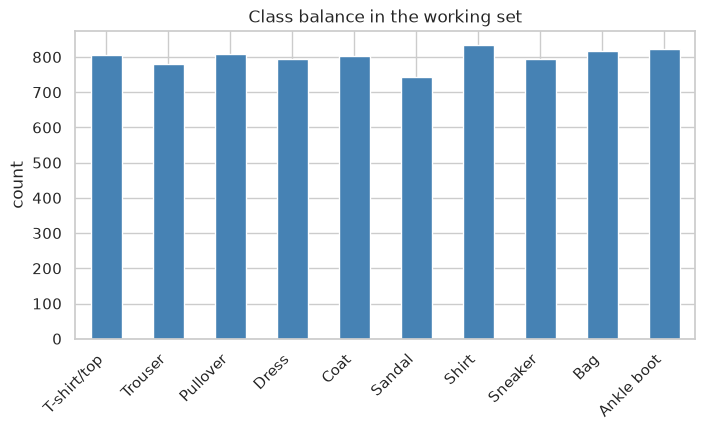

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
pd.Series([class_names[i] for i in y_all.numpy()]).value_counts()[class_names].plot.bar(ax=ax, color="steelblue")
ax.set_title("Class balance in the working set")
ax.set_ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.show()

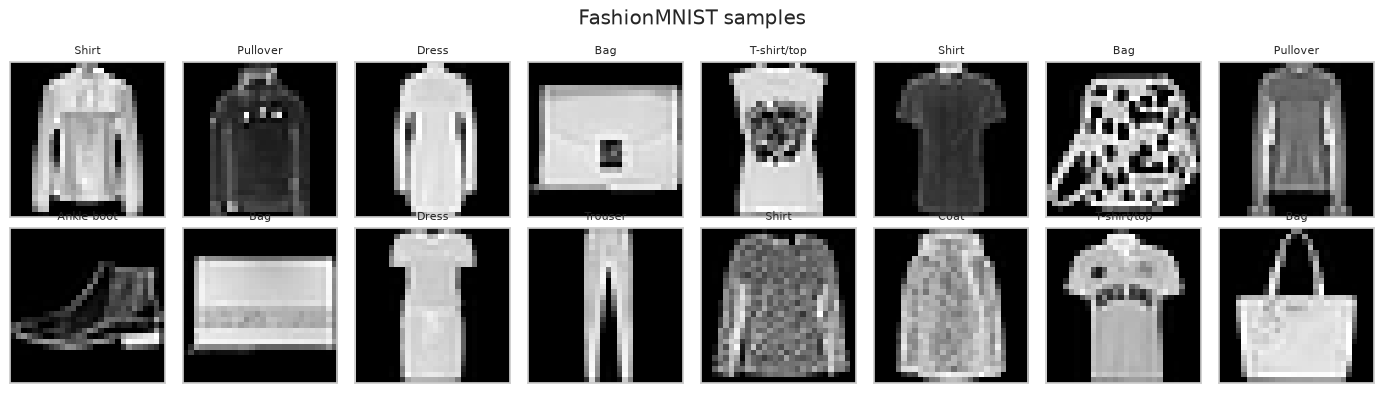

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_all[i, 0], cmap="gray")
    ax.set_title(class_names[y_all[i]], fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("FashionMNIST samples")
plt.tight_layout()
plt.show()

Classes are balanced (no need for `07_imbalanced_and_feature_selection`'s
techniques here), and a quick look at the samples already hints at the
main difficulty: T-shirt/Shirt/Pullover/Coat all look broadly similar at
this resolution — worth watching for in the confusion matrix later.

## 3. Data Preparation: Split, Normalize, Augment

Three-way split this time (train/val/test), not just train/test —
`12_training_deep_networks`'s early stopping needs a validation set
distinct from the test set we'll only touch once, at the very end.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_all.numpy(), y_all.numpy(), test_size=0.2, random_state=19, stratify=y_all.numpy()
)
X_train, X_val = torch.tensor(X_train), torch.tensor(X_val)
y_train, y_val = torch.tensor(y_train), torch.tensor(y_val)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Data augmentation for training only (05_deeper_cnns_transfer_learning): never augment val/test data
augmentation = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(28, padding=3)])

class AugmentedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

Train: 6400, Val: 1600, Test: 1500


## 4. Model Architecture

A CNN combining ideas from `14_cnn_fundamentals` (conv + pool blocks) and
`15_deeper_cnns_transfer_learning` (BatchNorm, a residual block).

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)

class CapstoneCNN(nn.Module):
    def __init__(self, n_classes=10, dropout_p=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2))  # 28->14
        self.res_block = ResidualBlock(16)
        self.block2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))  # 14->7
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(32 * 7 * 7, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.res_block(x)
        x = self.block2(x)
        x = self.dropout(x.flatten(1))
        return self.fc(x)

from torchinfo import summary
summary(CapstoneCNN(), input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CapstoneCNN                              [1, 1, 28, 28]            [1, 10]                   --
├─Sequential: 1-1                        [1, 1, 28, 28]            [1, 16, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 1, 28, 28]            [1, 16, 28, 28]           160
│    └─BatchNorm2d: 2-2                  [1, 16, 28, 28]           [1, 16, 28, 28]           32
│    └─ReLU: 2-3                         [1, 16, 28, 28]           [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 16, 28, 28]           [1, 16, 14, 14]           --
├─ResidualBlock: 1-2                     [1, 16, 14, 14]           [1, 16, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 16, 14, 14]           [1, 16, 14, 14]           2,320
│    └─BatchNorm2d: 2-6                  [1, 16, 14, 14]           [1, 16, 14, 14]           32
│    └─Conv2d: 2-7             

## 5. Training With Validation-Based Early Stopping

Adam optimizer, a `StepLR` schedule, and early stopping on validation
loss (`12_training_deep_networks`) — training stops automatically once
validation performance plateaus, and the best-epoch weights are restored.

In [7]:
def train_with_early_stopping(model, train_loader, X_val, y_val, max_epochs=30, lr=0.001, patience=6):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_val_loss, best_state, epochs_no_improve, stopped_at = float("inf"), None, 0, max_epochs
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_losses.append(epoch_loss / len(train_loader.dataset))
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            val_loss = criterion(val_out, y_val).item()
            val_acc = (val_out.argmax(1) == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss, best_state, epochs_no_improve = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                stopped_at = epoch
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, val_accs, stopped_at

## 6. A Small Design Comparison: Augmentation On vs. Off

Rather than assume augmentation helps, we check — same architecture, same
budget, only the training data pipeline differs.

In [8]:
def make_loader(augment):
    dataset = AugmentedDataset(X_train, y_train, transform=augmentation if augment else None)
    return DataLoader(dataset, batch_size=64, shuffle=True)

results = {}
for augment in [False, True]:
    torch.manual_seed(19)
    model = CapstoneCNN()
    loader = make_loader(augment)
    model, train_losses, val_losses, val_accs, stopped_at = train_with_early_stopping(model, loader, X_val, y_val)
    label = "with augmentation" if augment else "no augmentation"
    results[label] = {"model": model, "val_losses": val_losses, "val_accs": val_accs, "stopped_at": stopped_at}
    print(f"{label}: stopped at epoch {stopped_at}, best val loss={min(val_losses):.4f}, final val acc={val_accs[-1]:.3f}")

no augmentation: stopped at epoch 17, best val loss=0.2934, final val acc=0.895


with augmentation: stopped at epoch 30, best val loss=0.3195, final val acc=0.878


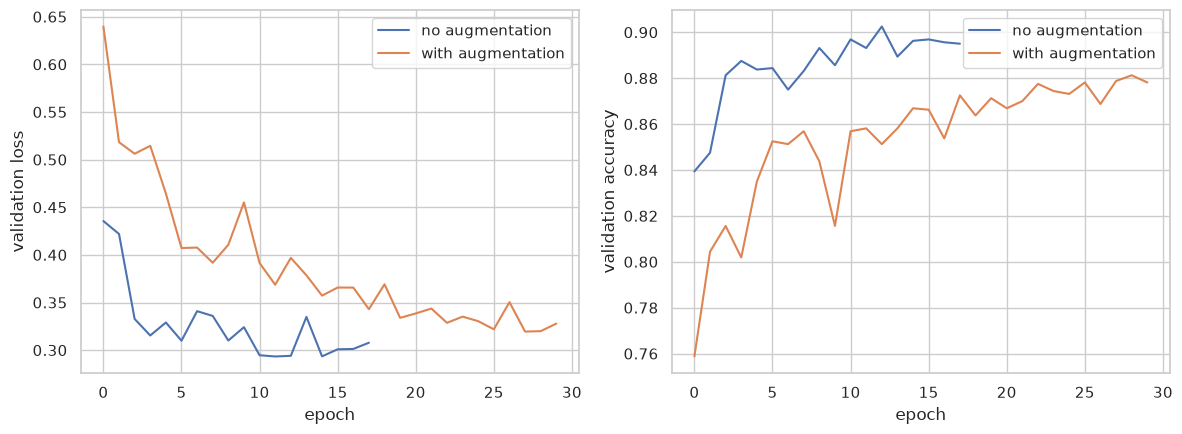

Selected for final evaluation: 'no augmentation'


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, r in results.items():
    axes[0].plot(r["val_losses"], label=label)
    axes[1].plot(r["val_accs"], label=label)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation loss"); axes[0].legend()
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

best_label = max(results, key=lambda k: results[k]["val_accs"][-1])
print(f"Selected for final evaluation: '{best_label}'")
best_model = results[best_label]["model"]

## 7. Final Evaluation on Held-Out Test Data

The test set has not been touched until this cell — a single, honest
estimate of generalization performance, exactly as in `09_capstone_project`.

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

best_model.eval()
with torch.no_grad():
    test_logits = best_model(X_test)
    y_pred = test_logits.argmax(1).numpy()

print(f"Test accuracy: {accuracy_score(y_test.numpy(), y_pred):.3f}\n")
print(classification_report(y_test.numpy(), y_pred, target_names=class_names))

Test accuracy: 0.894

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.85      0.85       148
     Trouser       0.99      0.98      0.99       156
    Pullover       0.80      0.88      0.84       163
       Dress       0.92      0.86      0.89       173
        Coat       0.79      0.85      0.82       153
      Sandal       0.98      0.97      0.98       150
       Shirt       0.74      0.62      0.68       126
     Sneaker       0.95      0.94      0.95       150
         Bag       0.94      0.98      0.96       140
  Ankle boot       0.95      0.98      0.97       141

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



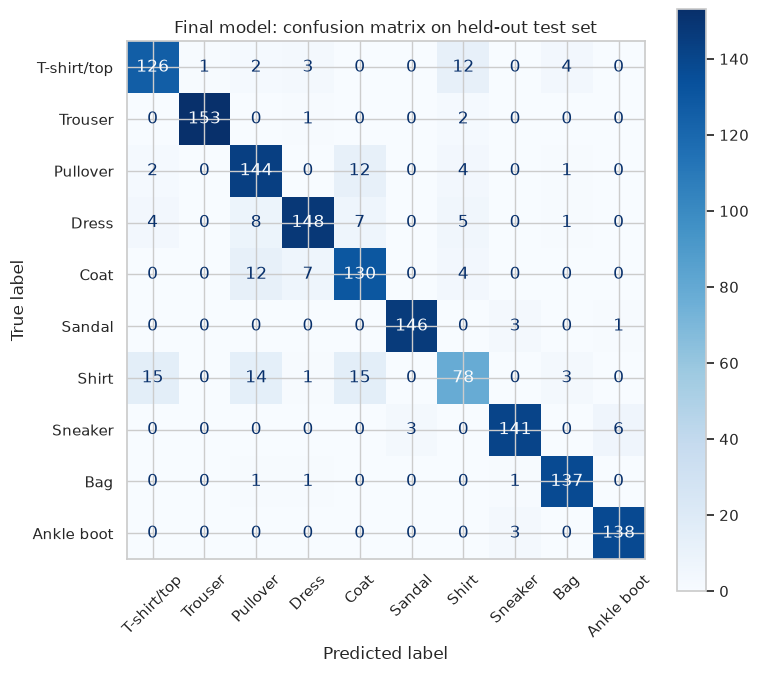

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test.numpy(), y_pred, display_labels=class_names, cmap="Blues", ax=ax, xticks_rotation=45,
)
ax.set_title("Final model: confusion matrix on held-out test set")
plt.tight_layout()
plt.show()

Check where the largest off-diagonal values land — if the EDA's hunch was
right, confusion should cluster among T-shirt/Shirt/Pullover/Coat rather
than being spread uniformly across all class pairs.

## 8. Interpretation: Filters and Misclassified Examples

Same techniques as `14_cnn_fundamentals`: look at what the first
convolutional layer learned, and look directly at what the model gets
wrong.

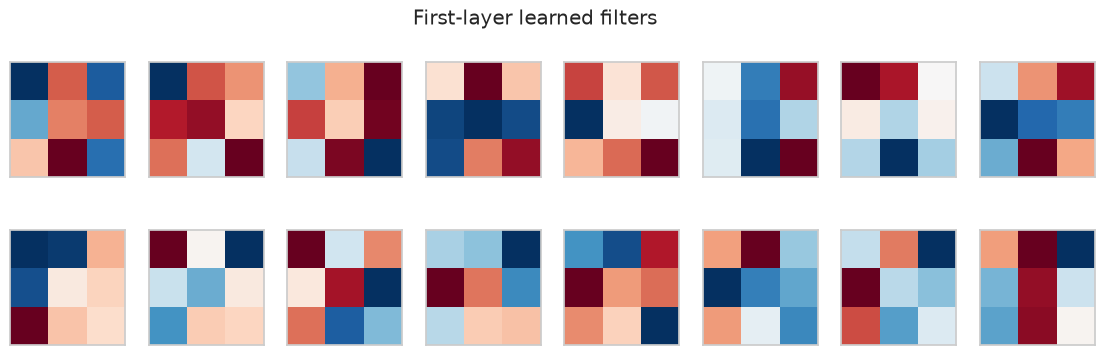

In [12]:
filters = best_model.stem[0].weight.detach()  # first conv layer, shape (16, 1, 3, 3)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="RdBu")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("First-layer learned filters")
plt.show()

159 of 1500 test images misclassified (10.6%)


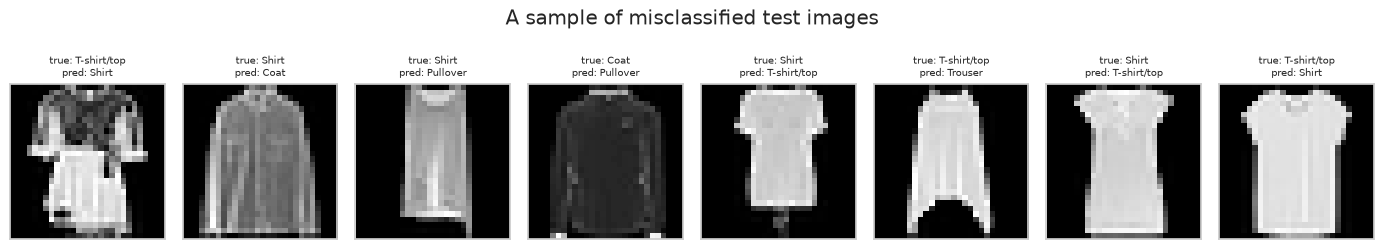

In [13]:
misclassified_idx = np.where(y_pred != y_test.numpy())[0]
print(f"{len(misclassified_idx)} of {len(y_test)} test images misclassified ({len(misclassified_idx)/len(y_test):.1%})")

sample_idx = rng.choice(misclassified_idx, size=min(8, len(misclassified_idx)), replace=False)
fig, axes = plt.subplots(1, len(sample_idx), figsize=(14, 2.3))
for ax, idx in zip(axes, sample_idx):
    ax.imshow(X_test[idx, 0], cmap="gray")
    ax.set_title(f"true: {class_names[y_test[idx]]}\npred: {class_names[y_pred[idx]]}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("A sample of misclassified test images", y=1.08)
plt.tight_layout()
plt.show()

Many of these misclassifications are ones a human might plausibly make
too at 28x28 resolution — a coat that looks like a pullover, a shirt with
sleeves cropped out looking like a T-shirt — evidence the model's errors
are reasonable, not arbitrary.

## 9. Summary

- **Problem:** classify FashionMNIST images into 10 clothing categories.
- **EDA:** balanced classes; visual similarity among T-shirt/Shirt/Pullover/Coat flagged as a likely confusion source.
- **Data prep:** a proper train/val/test split (val used only for early stopping/design decisions; test touched once, at the end), with augmentation applied to training data only.
- **Model:** a CNN combining BatchNorm and a residual block (Modules 14-15).
- **Training:** Adam + LR scheduling + validation-based early stopping (Module 12), avoiding the need to hand-pick a fixed epoch count.
- **Design comparison:** augmentation on vs. off, decided empirically on validation data rather than assumed.
- **Result:** see the printed test accuracy and classification report above; check the confusion matrix for exactly which classes the model still struggles to tell apart.
- **Interpretation:** learned filters and misclassified examples both inspected directly, rather than trusting the accuracy number alone.

### Where to go next
- Swap in the attention-based approach from `17_attention_and_transformers` (a Vision Transformer patches an image and self-attends across patches) as another architecture to compare against this CNN.
- Try the transfer-learning workflow from `15_deeper_cnns_transfer_learning` if you bring a new, smaller labeled dataset to this same pipeline.
- Add `06_model_selection_tuning`-style `GridSearchCV`/`RandomizedSearchCV`-equivalent hyperparameter sweeps (learning rate, dropout rate, channel widths) instead of the single augmentation on/off comparison here.
- Most importantly: rerun this **exact same 9-step structure** on image data of your own — that repetition, more than any single architecture, is what makes the full deep learning workflow stick, echoing the same closing note from `09_capstone_project`.